<a href="https://colab.research.google.com/github/PavanPk1/MyPractice_Colab_notebooks/blob/main/anova_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANOVA : Analysis Of Variance
- Used to compare multiple means
- It uses within sample sum of squares and between sample sum of squares
- F Statistic is Used

- H0 : All means are same
- H1 : All are not same ( At least one is different )

## One Way ANOVA
<img align = 'left' src = 'one-way-ANOVA-formulas.png' style = 'width:600px; hieght:400px' />

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import style
style.use('ggplot')

from statsmodels.formula.api import ols
import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [12]:
data = pd.read_excel('anova_datasets.xlsx')
data.head(10)

,Paint,Hardness,Temp,Operator
0,Blend 2,14.9,30.3,1
1,Blend 3,13.0,30.9,2
2,Blend 4,15.0,30.5,2
3,Blend 1,17.0,29.4,3
4,Blend 1,13.9,30.0,3
5,Blend 3,16.4,29.6,1
6,Blend 1,10.4,29.6,2
7,Blend 2,3.2,29.9,2
8,Blend 2,1.9,28.9,2
9,Blend 2,7.3,28.6,1


**Paint and Operator are 2 categorial variables in the data**

1.   List item
2.   List item




In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Paint     24 non-null     object 
 1   Hardness  24 non-null     float64
 2   Temp      24 non-null     float64
 3   Operator  24 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 900.0+ bytes


In [14]:
data.nunique()

,0
Paint,4
Hardness,24
Temp,15
Operator,3


* paint is one categorical variables.
* hardness is one quantitative variable.

In [15]:
print('Paints : ', data.Paint.unique())

Paints :  ['Blend 2' 'Blend 3' 'Blend 4' 'Blend 1']


<Axes: xlabel='Paint', ylabel='Hardness'>

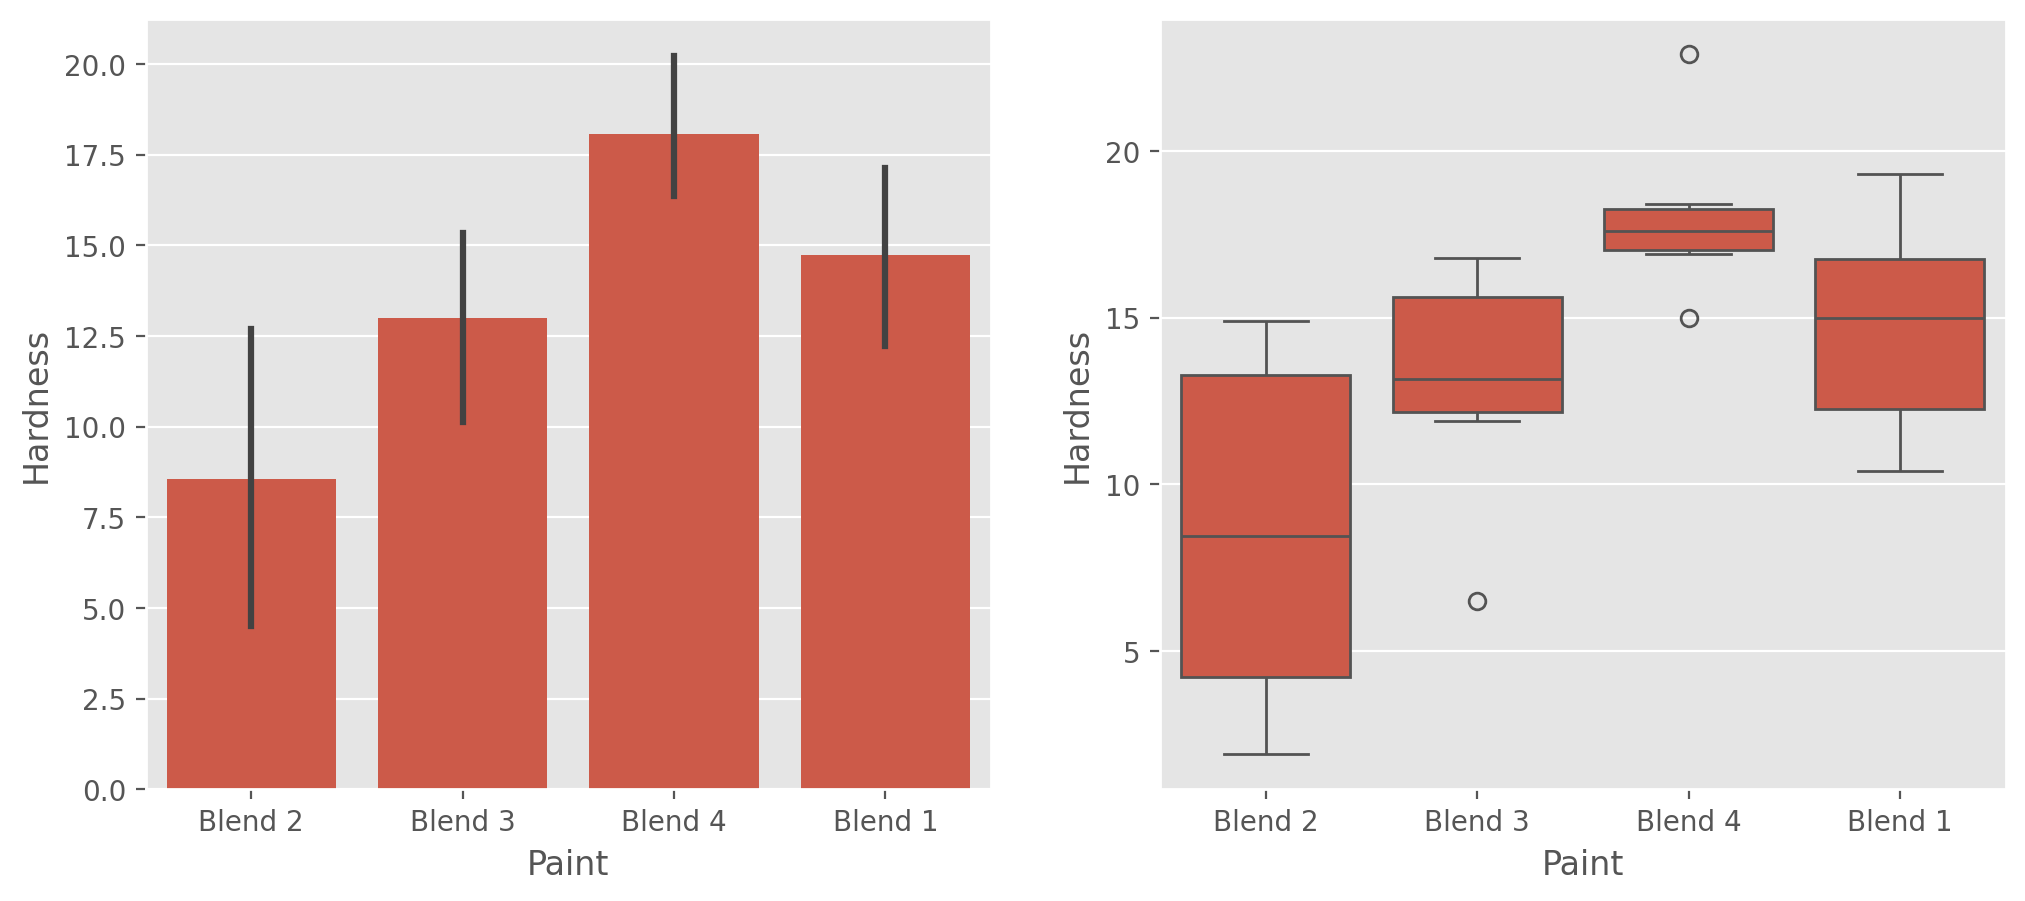

In [18]:
fig = plt.figure(figsize = (12,5), dpi = 200) # here we assgin it to fig variable
fig.add_subplot(1,2,1)  # so we used add_subplot or else we can use plt.subplot() directly
sns.barplot(x = data.Paint, y = data.Hardness)
fig.add_subplot(1,2,2)
sns.boxplot(x = data.Paint, y = data.Hardness)

Observation:


*   The blend 4 is not varing much (see box plot)
*   The blend 2 has more variance (std) fluctation in hardness.



In [20]:
model = ols('Hardness ~ C(Paint)', data = data).fit()

In [21]:
anova_tbl = sm.stats.anova_lm(model, typ = 1)
anova_tbl

,df,sum_sq,mean_sq,F,PR(>F)
C(Paint),3.0,281.697917,93.899306,6.017868,0.004297
Residual,20.0,312.068333,15.603417,NaN,NaN


In [22]:
# MSB
281.697917 / 3

93.89930566666668

In [23]:
# MSW
312.068333 / 20

15.60341665

In [24]:
# F-Statistic
f_statistic = 93.89930566666668 / 15.60341665
f_statistic

6.017868251096575

In [25]:
1 - stats.f.cdf(6.017868251096575, 3,20)

np.float64(0.004296566537500546)

In [26]:
alpha = 0.05 # significance level
stats.f.ppf(1 - alpha,3,20)

np.float64(3.09839121214078)

In [27]:
f_critical = 3.10

if f_statistic > f_critical:
    print('Reject Null Hypothesis')
else:
    print('Fail to reject Null Hypothesis')

Reject Null Hypothesis


There is a significant differnece for hardness for difference categories of paint.

## Two Way ANOVA
<img align = 'left' src = 'two-way-anova.png' style = 'width:600px; hieght:400px' />

In [31]:
toothdf = pd.read_excel('anova_datasets.xlsx', sheet_name = 'ToothGrowth')
toothdf.head(10)

,len,supp,dose
0,4.2,VC,0.5
1,11.5,VC,0.5
2,7.3,VC,0.5
3,5.8,VC,0.5
4,6.4,VC,0.5
5,10.0,VC,0.5
6,11.2,VC,0.5
7,11.2,VC,0.5
8,5.2,VC,0.5
9,7.0,VC,0.5


Question: Do supply, dose have any impact on length?

In [36]:
toothdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   len     60 non-null     float64
 1   supp    60 non-null     object 
 2   dose    60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.5+ KB


In [37]:
toothdf.nunique()

,0
len,43
supp,2
dose,3


In [38]:
toothdf.supp.unique()

array(['VC', 'OJ'], dtype=object)

In [39]:
toothdf.dose.unique()

array([0.5, 1. , 2. ])

<Axes: xlabel='dose', ylabel='len'>

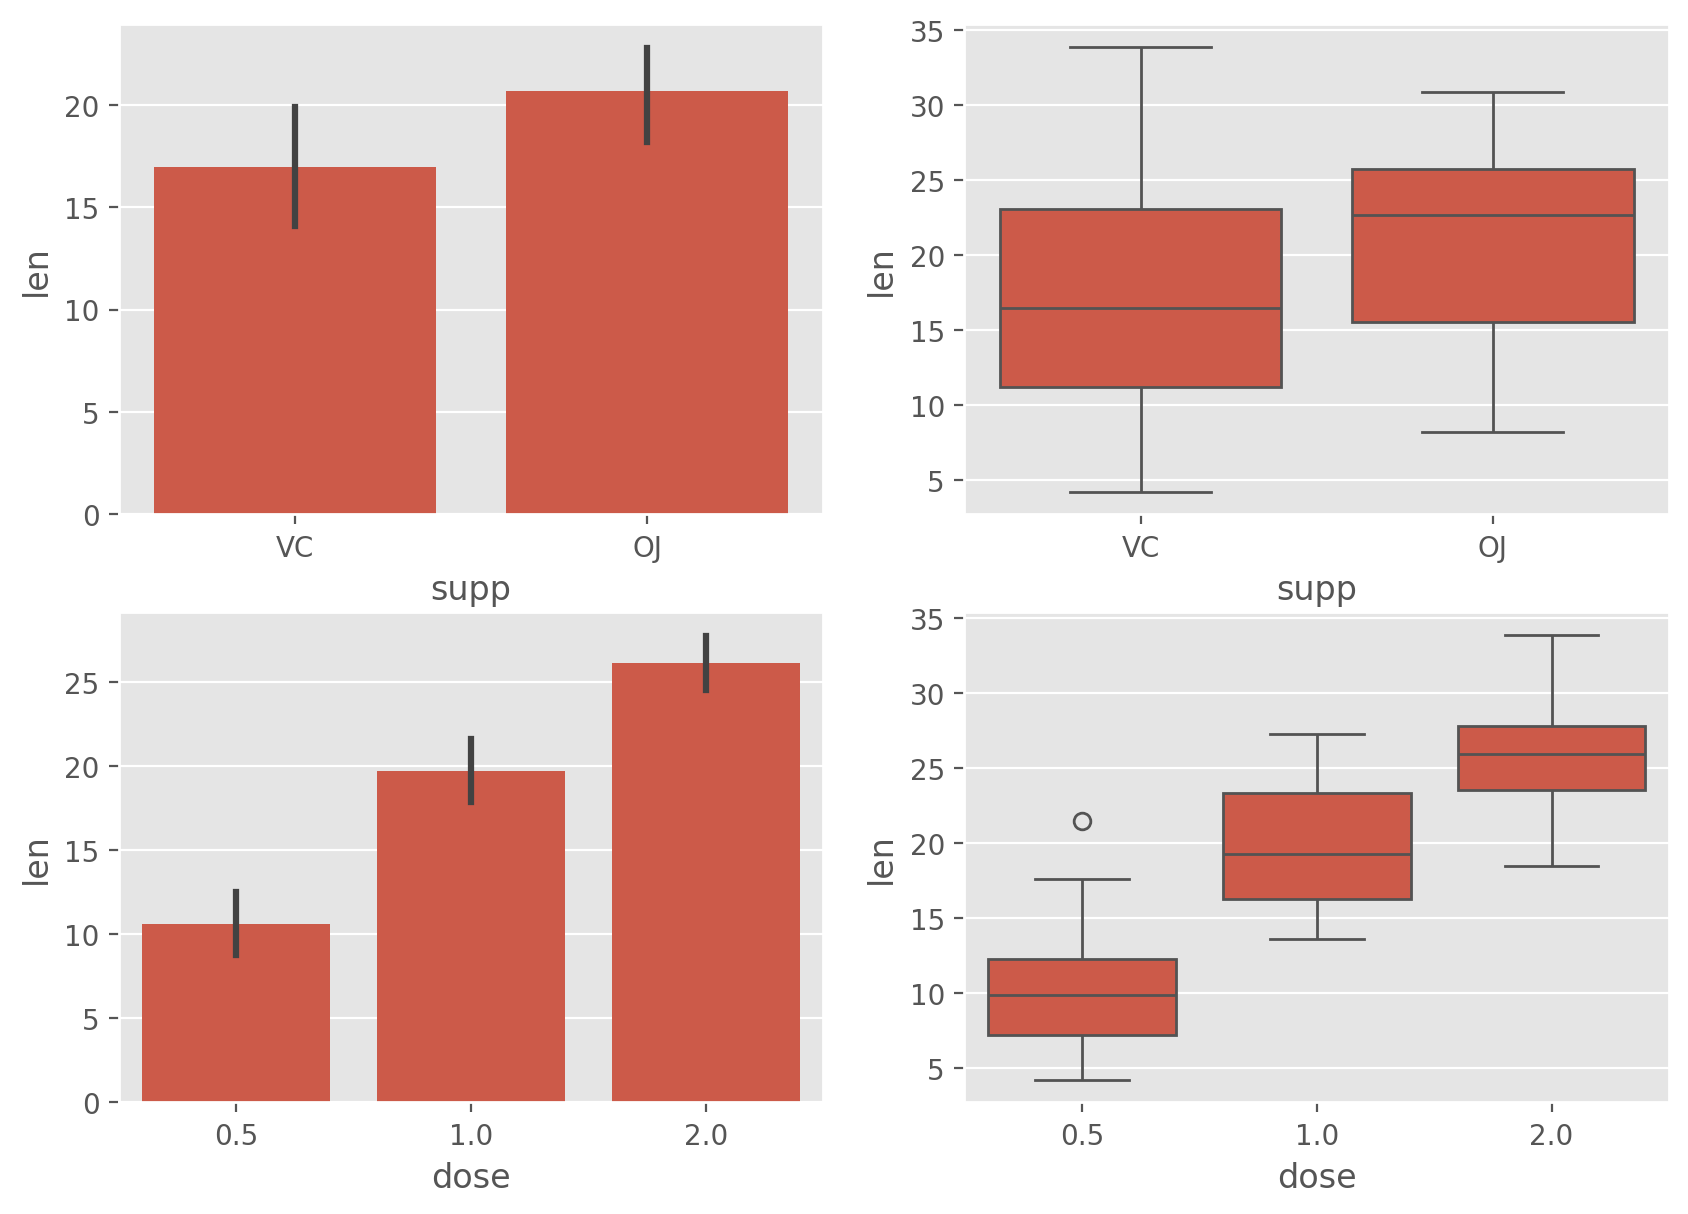

In [40]:
fig = plt.figure(figsize = (10,7), dpi = 200)
fig.add_subplot(2,2,1)
sns.barplot(x = toothdf.supp, y = toothdf.len)
fig.add_subplot(2,2,2)
sns.boxplot(x = toothdf.supp, y = toothdf.len)
fig.add_subplot(2,2,3)
sns.barplot(x = toothdf.dose, y = toothdf.len)
fig.add_subplot(2,2,4)
sns.boxplot(x = toothdf.dose, y = toothdf.len)

Observation:
*   OJ has less flatuations compared to len
*   increase in dose increses the len



In [41]:
model = ols('len ~ C(supp) + C(dose) + C(supp) : C(dose)', data = toothdf).fit()
anova_tbl = sm.stats.anova_lm(model, typ = 2)
anova_tbl

,sum_sq,df,F,PR(>F)
C(supp),205.350000,1.0,15.571979,2.311828e-04
C(dose),2426.434333,2.0,91.999965,4.046291e-18
C(supp):C(dose),108.319000,2.0,4.106991,2.186027e-02
Residual,712.106000,54.0,NaN,NaN


Formula Breakdown
'len ~ C(supp) + C(dose) + C(supp) : C(dose)' is a formula string specifying the model:

len is the dependent (response) variable.

C(supp) and C(dose) are categorical independent variables (factors). The C() indicates that these variables should be treated as categorical, not continuous.​

C(supp) : C(dose) represents the interaction term between the two categorical variables, meaning the effect of one factor depends on the level of the other.​

The + symbol adds main effects, while : adds the interaction effect.

In [ ]:
F_row = 15.571979
F_col = 91.999965
F_interaction = 4.106991

p_row = 1 - stats.f.cdf(F_row, 1,54)
p_col = 1 - stats.f.cdf(F_col, 2,54)
p_int = 1 - stats.f.cdf(F_interaction, 2, 54)

print("Factor A", p_row)
print("Factor B",p_col)
print("Interaction",p_int)

Factor A 0.00023118285265066874
Factor B 1.1102230246251565e-16
Interaction 0.02186027074878405


Conclusion:
* if the significance level is 0.05, all the factors will have the impact on the len.